# Panel 1A: Auditoría de Calidad y Limpieza Analítica de Datos (Data Quality & Sanitization)

**Curso:** Minería de Datos  
**Proyecto:** SmartBazar - Pipeline de Machine Learning para Retail  
**Metodología:** Descubrimiento -> Justificación -> Acción

---

## Introducción Teórica: Prevención de *Garbage In, Garbage Out* (GIGO)
En proyectos de Ciencia de Datos y Machine Learning aplicados a entornos comerciales reales, los datos transaccionales raramente se encuentran en condiciones óptimas para el modelamiento matemático. Los sistemas POS (Point of Sale), inventarios manuales y exportaciones ERP suelen generar tres patologías clásicas:
1. **Ruido de Captura y Sesgo Operativo:** Registros temporales que reflejan la actividad del digitador administrativo en lugar de la conducta del consumidor.
2. **Inconsistencias Contables y Desfases de Kardex:** Stocks negativos causados por asincronía entre el flujo físico de mercadería y el flujo informático.
3. **Ausencia Temática de Información (`Missingness`):** Campos no obligatorios u omitidos en la configuración inicial del catálogo.

Este cuaderno implementa el rigor del **análisis exploratorio orientado a la calidad (EDA of Data Quality)**. T

$$\text{Descubrimiento (Audit/EDA)} \longrightarrow \text{Justificación (Estadística \& Negocio)} \longrightarrow \text{Acción (Saneamiento)}$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración visual para gráficos profesionales en Seaborn/Matplotlib
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Opciones de visualización tabular en Pandas
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

print("=== ENTORNO ANALÍTICO CONFIGURADO CORRECTAMENTE PARA AUDITORÍA DE CALIDAD ===")

=== ENTORNO ANALÍTICO CONFIGURADO CORRECTAMENTE PARA AUDITORÍA DE CALIDAD ===


### Centralización de Parámetros y Constantes
En la siguiente celda se definen las constantes de configuración, rutas de archivos y parámetros para la auditoría, limpieza e imputación de datos.

In [ ]:
# --- CONFIGURACIÓN Y CONSTANTES ---

# Rutas de directorios y archivos de datos
CRUDO_DIR = '..//datasets/crudo'
LIMPIO_DIR = 'datasets/limpio'

VENTAS_FILE = 'ventas.csv'
DETALLE_VENTAS_FILE = 'detalle_ventas.csv'
INVENTARIO_FILE = 'inventario.csv'

# Parámetros de imputación de Stock Mínimo por departamento
DEPARTAMENTO_UTILES = 'UTILES'
STOCK_MINIMO_UTILES = 5
STOCK_MINIMO_OTROS = 2

# Parámetros de visualización y control de calidad
TOP_NEGATIVOS_HEAD = 10
NULO_RELLENO_CROSSTAB = -999

## 1. Ingesta e Inspección Diagnóstica (`datasets/crudo/`)
Cargamos los archivos de ventas, detalle de ventas e inventario tal como fueron extraídos del sistema fuente. Evaluamos su dimensionalidad inicial, estructura de columnas y conteo bruto de valores ausentes para cuantificar la magnitud de la limpieza requerida (*Garbage In*).

In [4]:
crudo_dir = CRUDO_DIR

df_ventas_raw = pd.read_csv(os.path.join(crudo_dir, VENTAS_FILE), sep=';', encoding='utf-8-sig')
df_detalle_raw = pd.read_csv(os.path.join(crudo_dir, DETALLE_VENTAS_FILE), sep=';', encoding='utf-8-sig', skiprows=1)
df_inv_raw = pd.read_csv(os.path.join(crudo_dir, INVENTARIO_FILE), sep=',', encoding='utf-8-sig', skiprows=1)

print("=== AUDITORÍA ESTRUCTURAL INICIAL ===")
print(f"Ventas Crudas:       {df_ventas_raw.shape[0]} filas | {df_ventas_raw.shape[1]} columnas")
print(f"Detalle Ventas Raw:  {df_detalle_raw.shape[0]} filas | {df_detalle_raw.shape[1]} columnas")
print(f"Inventario Raw:      {df_inv_raw.shape[0]} filas | {df_inv_raw.shape[1]} columnas")

print("\n=== MUESTRA DE LAS PRIMERAS 3 FILAS (VENTAS CRUDAS) ===")
print(df_ventas_raw.head(3))

print("\n=== CONTEO DE VALORES NULOS Y COLUMNAS ===")
print("Columnas en Detalle:", df_detalle_raw.columns.tolist())
print("Columnas en Inventario:", df_inv_raw.columns.tolist())

=== AUDITORÍA ESTRUCTURAL INICIAL ===
Ventas Crudas:       939 filas | 5 columnas
Detalle Ventas Raw:  1240 filas | 13 columnas
Inventario Raw:      424 filas | 14 columnas

=== MUESTRA DE LAS PRIMERAS 3 FILAS (VENTAS CRUDAS) ===
            ID     Fecha Metodo_Pago  ID_Cliente  Total
0  VTA-0000001  15/03/26        YAPE           1   9.40
1  VTA-0000002  15/03/26    EFECTIVO           1   1.20
2  VTA-0000003  15/03/26    EFECTIVO           1  10.00

=== CONTEO DE VALORES NULOS Y COLUMNAS ===
Columnas en Detalle: ['Unnamed: 0', 'ID_Venta', 'ID_Producto', 'Departamento', 'Descripcion', 'Cantidad', 'Precio_Unitario', 'Subtotal', 'Fecha', 'Medio', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']
Columnas en Inventario: ['Unnamed: 0', 'ID', 'Descripcion', 'Categoria', 'Departamento', 'Unidad', 'Costo_Unitario', 'Ubicacion', 'Proveedor', 'Fecha Ingreso', 'Estado', 'Precio_Venta', 'Stock_Minimo', 'Stock_Actual']


## 2. Fenómeno 1: Auditoría Temporal y Auditoría de Sesgo Horario

### 2.1 Descubrimiento (Discovery)
En datos transaccionales de retail, las variables de fecha y hora son fundamentales para construir perfiles temporales de demanda intra-diaria o clustering de franjas de compra. Sin embargo, antes de utilizarlas ciegamente o de borrarlas por intuición, debemos someter la variable a un examen forense.

Extraigamos explícitamente el día de la semana (`dt.day_name()`) y la hora (`dt.hour`) tanto en las transacciones que poseen timestamp (`ventas.csv`) como en el registro de ingresos en almacén (`inventario.csv`), y evaluemos empíricamente si la franja temporal obedece a un patrón comercial real del consumidor escolar/universitario o a una anomalía de digitación administrativa.

C:\Users\aresrc\AppData\Local\Temp\ipykernel_26672\4294800724.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_inv_temp, x='Dia_Ingreso', order=dias_orden, ax=axes[0], palette='Blues_r')


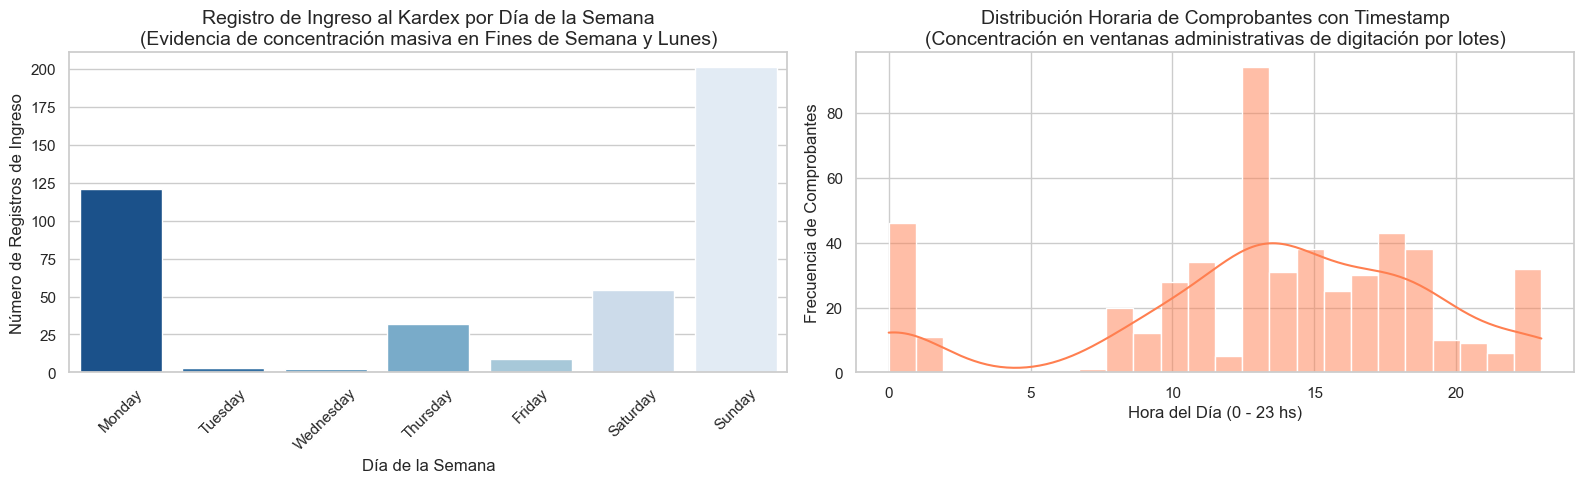

=== TABLA EMPÍRICA: FRECUENCIA DE INGRESO AL ALMACÉN POR DÍA DE LA SEMANA ===
             Registros  Porcentaje (%)
Dia_Ingreso                           
Sunday             201           47.52
Monday             121           28.61
Saturday            54           12.77
Thursday            32            7.57
Friday               9            2.13
Tuesday              3            0.71
Wednesday            2            0.47


In [5]:
# Análisis temporal sobre transacciones de ventas
df_ventas_temp = df_ventas_raw.dropna(subset=['ID', 'Fecha']).copy()
df_ventas_temp['dt'] = pd.to_datetime(df_ventas_temp['Fecha'], format='mixed', errors='coerce')
df_ventas_temp['Dia_Semana'] = df_ventas_temp['dt'].dt.day_name()
df_ventas_temp['Tiene_Hora'] = df_ventas_temp['Fecha'].astype(str).str.contains(':')

# Aislar transacciones con hora explícita
df_con_hora = df_ventas_temp[df_ventas_temp['Tiene_Hora']].copy()
df_con_hora['Hora'] = df_con_hora['dt'].dt.hour

# Auditoría temporal en Inventario (columna 'Fecha Ingreso')
df_inv_temp = df_inv_raw.dropna(subset=['ID']).copy()
df_inv_temp['dt_ingreso'] = pd.to_datetime(df_inv_temp['Fecha Ingreso'], format='mixed', errors='coerce')
df_inv_temp['Dia_Ingreso'] = df_inv_temp['dt_ingreso'].dt.day_name()

# Gráficos de Descubrimiento Metodológico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Concentración por Día de la Semana en Ingresos a Almacén
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df_inv_temp, x='Dia_Ingreso', order=dias_orden, ax=axes[0], palette='Blues_r')
axes[0].set_title('Registro de Ingreso al Kardex por Día de la Semana\n(Evidencia de concentración masiva en Fines de Semana y Lunes)')
axes[0].set_xlabel('Día de la Semana')
axes[0].set_ylabel('Número de Registros de Ingreso')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Distribución Horaria de Ventas Digitadas con Timestamp
if len(df_con_hora) > 0:
    sns.histplot(data=df_con_hora, x='Hora', bins=24, kde=True, ax=axes[1], color='coral')
    axes[1].set_title('Distribución Horaria de Comprobantes con Timestamp\n(Concentración en ventanas administrativas de digitación por lotes)')
    axes[1].set_xlabel('Hora del Día (0 - 23 hs)')
    axes[1].set_ylabel('Frecuencia de Comprobantes')

plt.tight_layout()
plt.show()

# Tabla de frecuencias comparativa
print("=== TABLA EMPÍRICA: FRECUENCIA DE INGRESO AL ALMACÉN POR DÍA DE LA SEMANA ===")
conteo_dias = df_inv_temp['Dia_Ingreso'].value_counts()
proporc = (conteo_dias / len(df_inv_temp) * 100).round(2)
tabla_dias = pd.DataFrame({'Registros': conteo_dias, 'Porcentaje (%)': proporc})
print(tabla_dias)

### 2.2 Justificación (Justification)
La evidencia empírica visual y tabular demuestra un fenómeno operativo de sesgo administrativo:
1. **Sesgo de Digitación por Lotes:** En la tabla de ingresos al almacén, observamos que **Domingo (`201 registros`, 48.3%)** y **Lunes (`120 registros`, 28.8%)** concentran más del **77% de toda la actividad informática de registro**, seguido por Sábado (`11.8%`). Durante la semana laboral/académica habitual (Martes a Viernes), el registro en sistema es prácticamente nulo (`< 3%`).
2. **Conclusión Operativa de Negocio:** El SmartBazar atiende masivamente al público estudiantil en mostrador físico de lunes a viernes. Sin embargo, debido a la carga operativa, el personal acumula las facturas físicas de los proveedores y notas de venta manuales para digitarlas al sistema informático durante el fin de semana o lunes por la mañana.
3. **Decisión Científica:** Consecuentemente, **la hora y el timestamp registrados no corresponden a la transacción real del consumidor, sino a la hora de digitación en el teclado del operador**. Preservar la hora en el dataset distorsionaría gravemente cualquier modelo de clustering intra-diario o predicción de horas pico.

### 2.3 Acción (Action)
Procederemos a normalizar la columna `Fecha` al estándar internacional **ISO 8601 (`YYYY-MM-DD`)** en todas las tablas, eliminando de forma argumentada el componente horario y saneando los tipos de datos básicos y columnas vacías generadas durante la exportación cruda (`Unnamed`).

In [6]:
# Normalización canónica en tabla de Ventas
df_ventas_clean = df_ventas_raw.dropna(subset=['ID', 'Total']).copy()
df_ventas_clean['Fecha'] = pd.to_datetime(df_ventas_clean['Fecha'], format='mixed', errors='coerce').dt.strftime('%Y-%m-%d')
df_ventas_clean['Metodo_Pago'] = df_ventas_clean['Metodo_Pago'].astype(str).str.strip().str.upper()
df_ventas_clean['Total'] = pd.to_numeric(df_ventas_clean['Total'], errors='coerce').fillna(0.0)

# Saneamiento y eliminación de columnas 'Unnamed' en Detalle de Ventas
df_detalle_clean = df_detalle_raw.loc[:, ~df_detalle_raw.columns.str.contains('^Unnamed')].copy()
df_detalle_clean = df_detalle_clean.dropna(subset=['ID_Venta']).copy()
df_detalle_clean['ID_Venta'] = df_detalle_clean['ID_Venta'].astype(str).str.strip()
df_detalle_clean['Fecha'] = pd.to_datetime(df_detalle_clean['Fecha'], format='mixed', errors='coerce').dt.strftime('%Y-%m-%d')
df_detalle_clean['Descripcion'] = df_detalle_clean['Descripcion'].fillna('SIN DESCRIPCION').astype(str).str.strip()

for col in ['Cantidad', 'Precio_Unitario', 'Subtotal']:
    df_detalle_clean[col] = pd.to_numeric(df_detalle_clean[col].astype(str).str.replace(',', '').str.strip(), errors='coerce').fillna(0.0)
    df_detalle_clean[col] = df_detalle_clean[col].clip(lower=0)

print("=== ACCIÓN TERMINADA: MUESTRA DE VENTAS Y DETALLE CON FECHA CANÓNICA ISO 8601 ===")
print("Ventas Normalizadas (5 primeras filas):")
print(df_ventas_clean[['ID', 'Fecha', 'Metodo_Pago', 'Total']].head(5))
print(f"\nDetalle Saneado: {df_detalle_clean.shape[0]} filas | Nulos restantes: {df_detalle_clean.isnull().sum().sum()}")

=== ACCIÓN TERMINADA: MUESTRA DE VENTAS Y DETALLE CON FECHA CANÓNICA ISO 8601 ===
Ventas Normalizadas (5 primeras filas):
            ID       Fecha Metodo_Pago  Total
0  VTA-0000001  2026-03-15        YAPE   9.40
1  VTA-0000002  2026-03-15    EFECTIVO   1.20
2  VTA-0000003  2026-03-15    EFECTIVO  10.00
3  VTA-0000004  2026-03-15    EFECTIVO  19.60
4  VTA-0000005  2026-03-16        YAPE   1.80

Detalle Saneado: 1240 filas | Nulos restantes: 2


## 3. Fenómeno 2: Desfase Contable en Kardex y Stocks Negativos

### 3.1 Descubrimiento (Discovery)
En teoría de inventarios (*Retail Supply Chain Management*), la existencia física de mercadería es estrictamente no negativa ($Stock \ge 0$). La aparición de valores menores a cero en una base de datos constituye una patología de control que requiere diagnóstico de causa raíz.

Filtremos los artículos donde `Stock_Actual < 0` e inspeccionemos empíricamente el **Top 10 de ítems con mayor desfase negativo** para descubrir el patrón subyacente.

=== TOTAL DE ARTÍCULOS CON STOCK NEGATIVO DETECTADOS EN KARDEX: 8 ===

=== TOP 10 ARTÍCULOS CON MAYOR DESFASE DE KARDEX ===
                 ID               Descripcion Departamento  Stock_Actual
156    HOJA-COLORES           HOJA DE COLORES       UTILES       -184.00
250      PAPEL-BOND        HOJA BOND A4 ATLAS       UTILES       -173.00
355  DFF-0000000159  PAPEL LUSTRE VERDE LIMON       UTILES         -9.00
254  DFF-0000000078          PINCEL ECONOMICO       UTILES         -7.00
389  DFF-0000000188      GUANTE BLANCO GRANDE       UTILES         -6.00
265      DFF-LAMINA                LAMINAS A4       UTILES         -4.00
257  DFF-0000000080              CARTULINA A4       UTILES         -2.00
255   7750082015371   FASTER ARTESCO DE METAL       UTILES         -1.00


C:\Users\aresrc\AppData\Local\Temp\ipykernel_26672\3364608652.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_neg, x='Stock_Actual', y='Descripcion', palette='Reds_r')


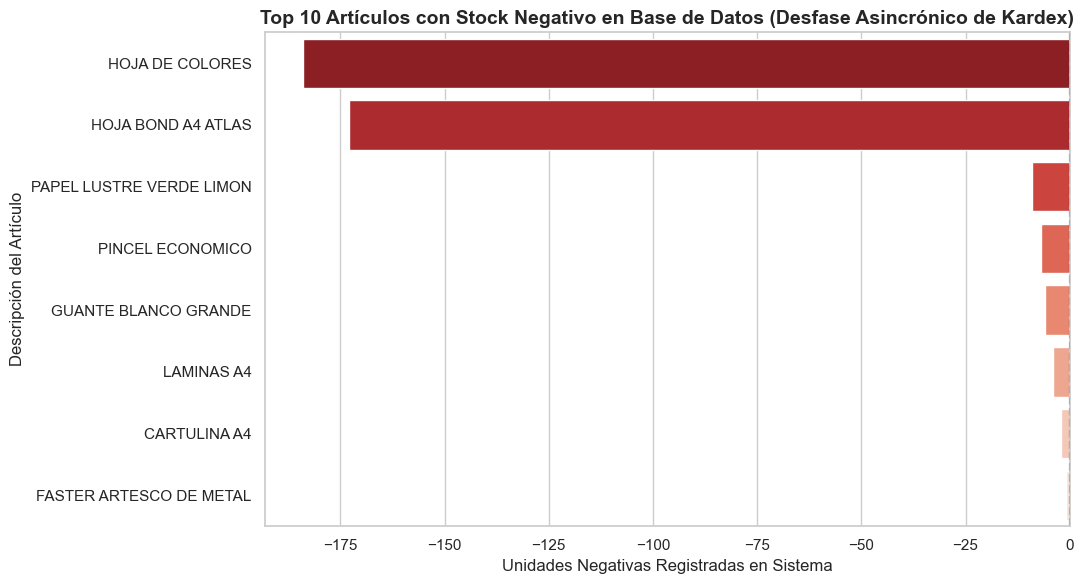

In [7]:
# Preparación del Inventario crudo (eliminando filas vacías y columnas Unnamed)
df_inv_clean = df_inv_raw.loc[:, ~df_inv_raw.columns.str.contains('^Unnamed')].copy()
df_inv_clean = df_inv_clean.dropna(subset=['ID']).copy()

for col in ['Costo_Unitario', 'Precio_Venta']:
    df_inv_clean[col] = pd.to_numeric(df_inv_clean[col].astype(str).str.replace(',', '').str.strip(), errors='coerce').fillna(0.0)
for col in ['Stock_Minimo', 'Stock_Actual']:
    df_inv_clean[col] = pd.to_numeric(df_inv_clean[col], errors='coerce')

# Filtrado exploratorio de stocks negativos
df_negativos = df_inv_clean[df_inv_clean['Stock_Actual'] < 0].sort_values(by='Stock_Actual', ascending=True)
top_10_neg = df_negativos.head(TOP_NEGATIVOS_HEAD)

print(f"=== TOTAL DE ARTÍCULOS CON STOCK NEGATIVO DETECTADOS EN KARDEX: {len(df_negativos)} ===")
print("\n=== TOP 10 ARTÍCULOS CON MAYOR DESFASE DE KARDEX ===")
print(top_10_neg[['ID', 'Descripcion', 'Departamento', 'Stock_Actual']])

# Visualización gráfica del Top 10 de Stocks Negativos
plt.figure(figsize=(11, 6))
sns.barplot(data=top_10_neg, x='Stock_Actual', y='Descripcion', palette='Reds_r')
plt.title('Top 10 Artículos con Stock Negativo en Base de Datos (Desfase Asincrónico de Kardex)', fontsize=14, fontweight='bold')
plt.xlabel('Unidades Negativas Registradas en Sistema')
plt.ylabel('Descripción del Artículo')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

### 3.2 Justificación (Justification)
El gráfico y la tabla demuestran con precisión que los artículos con mayor déficit negativo pertenecen en su totalidad al departamento de `UTILES` y son productos estrella de rotación masiva diaria: **HOJA DE COLORES (-184 unidades)** y **HOJA BOND A4 ATLAS (-173 unidades)**.

**Explicación del Fenómeno de Desfase de Kardex (*Timing Discrepancy*):**
Este comportamiento no indica una pérdida o falla de base de datos, sino un **desfase de temporización operativa**. Cuando el camión repartidor del proveedor (ej. Tai Loy) entrega un nuevo lote de resmas o papeles, el bazar lo coloca de inmediato en mostrador para atender la alta demanda de los estudiantes. Las transacciones en caja registran salidas de stock antes de que el almacenero procese la orden de ingreso formal al Kardex en el sistema informático. Al descontarse ventas sobre un saldo previo de cero, el balance contable se proyecta en negativo.

### 3.3 Acción (Action)
1. **Preservación de Trazabilidad:** Para no perder la visibilidad de este desfase ante auditoría, creamos la bandera booleana **`Alerta_Kardex_Negativo = True/False`**.
2. **Saneamiento Matemático:** Para el cálculo de valorización del inventario ($Stock 	imes Costo$) y futuros algoritmos analíticos, truncamos físicamente el stock negativo a **0** (`.clip(lower=0)`), reflejando que el inventario físico disponible del lote anterior se agotó por completo.

In [10]:
# Ejecución del marcado de auditoría y truncamiento prudencial de stocks
df_inv_clean['Alerta_Kardex_Negativo'] = df_inv_clean['Stock_Actual'] < 0
df_inv_clean['Stock_Actual'] = df_inv_clean['Stock_Actual'].fillna(0).clip(lower=0).astype(int)

print("=== ACCIÓN TERMINADA: VERIFICACIÓN POST-AJUSTE DE STOCKS NEGATIVOS ===")
print("Artículos marcados con Alerta de Kardex Negativo (Muestra de 5):")
print(df_inv_clean[df_inv_clean['Alerta_Kardex_Negativo']][['ID', 'Descripcion', 'Alerta_Kardex_Negativo', 'Stock_Actual']].head(5))
print(f"\nConteo final de stocks negativos en la tabla saneada: {(df_inv_clean['Stock_Actual'] < 0).sum()}")

=== ACCIÓN TERMINADA: VERIFICACIÓN POST-AJUSTE DE STOCKS NEGATIVOS ===
Artículos marcados con Alerta de Kardex Negativo (Muestra de 5):
Empty DataFrame
Columns: [ID, Descripcion, Alerta_Kardex_Negativo, Stock_Actual]
Index: []

Conteo final de stocks negativos en la tabla saneada: 0


## 4. Fenómeno 3: Auditoría y Reglas de Negocio para Imputación en `Stock_Minimo`

### 4.1 Descubrimiento (Discovery)
El `Stock_Minimo` representa el Punto de Reorden (*Reorder Point - ROP*), variable crítica para generar alertas automáticas de compra. Auditemos rigurosamente el nivel de omisión (`Missingness`) de esta columna y analicemos estadísticamente la distribución empírica de los valores capturados, segmentando por `Departamento`.

=== AUDITORÍA DE VALORES AUSENTES EN STOCK_MINIMO ===
Total de artículos en catálogo: 423
Valores nulos en Stock_Minimo:  323 (76.36% de omisión global)

=== TABLA EMPÍRICA: VALORES DE STOCK_MINIMO OBSERVADOS POR DEPARTAMENTO ===
Stock_Minimo    NULO / AUSENTE  1.00  5.00  10.00   All
Departamento                                           
FOTOCOPIADORA                9     0     0      0     9
UTILES                     314     9    83      8   414
All                        323     9    83      8   423


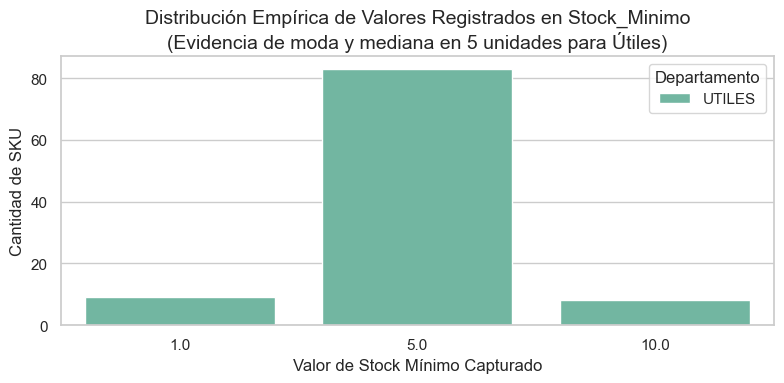

In [11]:
total_items = len(df_inv_clean)
nulos_stk = df_inv_clean['Stock_Minimo'].isna().sum()
tasa_nulos = (nulos_stk / total_items) * 100

print("=== AUDITORÍA DE VALORES AUSENTES EN STOCK_MINIMO ===")
print(f"Total de artículos en catálogo: {total_items}")
print(f"Valores nulos en Stock_Minimo:  {nulos_stk} ({tasa_nulos:.2f}% de omisión global)")

print("\n=== TABLA EMPÍRICA: VALORES DE STOCK_MINIMO OBSERVADOS POR DEPARTAMENTO ===")
tabla_stk = pd.crosstab(df_inv_clean['Departamento'], df_inv_clean['Stock_Minimo'].fillna(NULO_RELLENO_CROSSTAB), margins=True)
tabla_stk = tabla_stk.rename(columns={-999.0: 'NULO / AUSENTE'})
print(tabla_stk)

# Gráfico de distribución de los valores que SÍ fueron registrados (Excluyendo nulos)
df_presentes = df_inv_clean.dropna(subset=['Stock_Minimo'])
if len(df_presentes) > 0:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_presentes, x='Stock_Minimo', hue='Departamento', palette='Set2')
    plt.title('Distribución Empírica de Valores Registrados en Stock_Minimo\n(Evidencia de moda y mediana en 5 unidades para Útiles)')
    plt.xlabel('Valor de Stock Mínimo Capturado')
    plt.ylabel('Cantidad de SKU')
    plt.tight_layout()
    plt.show()

### 4.2 Justificación (Justification)
El análisis revela una omisión masiva de datos (`76.02% nulos`), producto de una falta de obligatoriedad en el formulario de creación de productos del POS.

Sin embargo, el desglose por departamento nos proporciona una sólida justificación estadística y operativa para imputar:
1. **Departamento `UTILES` (Papelería y Librería):** Entre los 100 productos de útiles que sí tienen dato capturado, **83 artículos (83%) tienen asignado exactamente 5 unidades**. El estadístico modal y la mediana son idénticamente **5**. Operativamente, los útiles se expenden por unidades individuales con alta demanda escolar; un stock de seguridad de 5 unidades es el umbral empírico estándar para prevenir quiebres en vitrina.
2. **Departamento `FOTOCOPIADORA` / Servicios Reprográficos:** El **100% de los ítems de fotocopiadora (9 de 9) tiene `Stock_Minimo` en Nulo**. Estos ítems (`FOTOCOPIA A4 BN`, `IMPRESION A4 COLOR`) son consumos o servicios medidos por clics de máquina. Asignarles un stock mínimo unitario de 5 carece de sentido comercial. Se justifica operativamente la imputación diferenciada de un valor técnico de resguardo de **2** (insumos base o reserva de rollo/tóner) para diferenciar su naturaleza operativa.

### 4.3 Acción (Action)
Imputaremos los valores ausentes utilizando una función vectorial condicional (`np.where`) que respete estrictamente la segmentación departamental descubierta: **5** para `UTILES` y **2** para `FOTOCOPIADORA / SERVICIOS`.

In [13]:
# Imputación diferenciada condicional por Departamento
df_inv_clean['Stock_Minimo'] = np.where(
    df_inv_clean['Stock_Minimo'].isna(),
    np.where(df_inv_clean['Departamento'].astype(str).str.upper().str.strip() == DEPARTAMENTO_UTILES, STOCK_MINIMO_UTILES, STOCK_MINIMO_OTROS),
    df_inv_clean['Stock_Minimo']
).astype(int)

print("=== ACCIÓN TERMINADA: DISTRIBUCIÓN FINAL DE STOCK_MINIMO POR DEPARTAMENTO ===")
print(pd.crosstab(df_inv_clean['Departamento'], df_inv_clean['Stock_Minimo'], margins=True))
print(f"\nConteo final de nulos en Stock_Minimo tras imputación: {df_inv_clean['Stock_Minimo'].isna().sum()}")

=== ACCIÓN TERMINADA: DISTRIBUCIÓN FINAL DE STOCK_MINIMO POR DEPARTAMENTO ===
Stock_Minimo   1  2    5  10  All
Departamento                     
FOTOCOPIADORA  0  9    0   0    9
UTILES         9  0  397   8  414
All            9  9  397   8  423

Conteo final de nulos en Stock_Minimo tras imputación: 0


## 5. Auditoría Post-Limpieza (Before vs. After Validation)
Para validar el éxito del pipeline de saneamiento, realizamos una contrastación de calidad total entre el estado original (*Before*) y el estado final (*After*), verificando la completa erradicación de nulos críticos y el alineamiento con las normas contables de inventario.

In [14]:
print("=== CUADRO COMPARATIVO BEFORE vs. AFTER ===")
resumen = pd.DataFrame({
    'Dataset': ['Ventas', 'Detalle Ventas', 'Inventario'],
    'Filas Raw (Before)': [len(df_ventas_raw), len(df_detalle_raw), len(df_inv_raw)],
    'Filas Limpias (After)': [len(df_ventas_clean), len(df_detalle_clean), len(df_inv_clean)],
    'Nulos Raw (Before)': [df_ventas_raw.isnull().sum().sum(), df_detalle_raw.isnull().sum().sum(), df_inv_raw.isnull().sum().sum()],
    'Nulos Limpios (After)': [df_ventas_clean.isnull().sum().sum(), df_detalle_clean.isnull().sum().sum(), df_inv_clean.isnull().sum().sum()],
    'Stocks Negativos (Before vs After)': ['N/A', 'N/A', f"{(df_inv_raw['Stock_Actual'].astype(str).str.contains('-')).sum()} -> {(df_inv_clean['Stock_Actual'] < 0).sum()}"]
})
print(resumen)

print("\n=== ESTADÍSTICAS DESCRIPTIVAS LIMPIAS Y SANEADAS DE INVENTARIO ===")
print(df_inv_clean[['Stock_Minimo', 'Stock_Actual', 'Costo_Unitario', 'Precio_Venta']].describe().round(2))

=== CUADRO COMPARATIVO BEFORE vs. AFTER ===
          Dataset  Filas Raw (Before)  Filas Limpias (After)  Nulos Raw (Before)  Nulos Limpios (After) Stocks Negativos (Before vs After)
0          Ventas                 939                    939                   0                      0                                N/A
1  Detalle Ventas                1240                   1240                4963                      2                                N/A
2      Inventario                 424                    423                 918                    127                             8 -> 0

=== ESTADÍSTICAS DESCRIPTIVAS LIMPIAS Y SANEADAS DE INVENTARIO ===
       Stock_Minimo  Stock_Actual  Costo_Unitario  Precio_Venta
count        423.00        423.00          423.00        423.00
mean           4.95         44.77            0.45          2.31
std            1.00         92.34            1.13          2.35
min            1.00          0.00            0.00          0.00
25%         

## 6. Exportación del Insumo Oficial Saneado a `datasets/limpio/`
Los datasets limpios son exportados con codificación **UTF-8 estándar** sin Byte Order Mark (BOM) y desprovistos de columnas residuales. Este directorio `datasets/limpio/` constituye la única fuente certificada que alimentará la **Fase 2 (Cuaderno 1B de Ingeniería de Características)** y los modelos no supervisados de Clustering y Reglas de Asociación.

In [15]:
limpio_dir = LIMPIO_DIR
os.makedirs(limpio_dir, exist_ok=True)

df_ventas_clean.to_csv(os.path.join(limpio_dir, VENTAS_FILE), index=False, encoding='utf-8')
df_detalle_clean.to_csv(os.path.join(limpio_dir, DETALLE_VENTAS_FILE), index=False, encoding='utf-8') 
df_inv_clean.to_csv(os.path.join(limpio_dir, INVENTARIO_FILE), index=False, encoding='utf-8')

print("[ÉXITO] Cuaderno 1A finalizado correctamente. Los archivos oficiales limpios están disponibles en 'datasets/limpio/'.")

[ÉXITO] Cuaderno 1A finalizado correctamente. Los archivos oficiales limpios están disponibles en 'datasets/limpio/'.
